# 93 - Öğrenme, varyansın içindeki payı

**İzole notebook.** Zincirin (01-06) hiçbir parçası bunu okumaz.

## Soru

`92_varyans_ayrisimi.ipynb` varyansı üçe ayırdı: kişi / koşul / artık. Ama orada öğrenme
kendi başına bir bileşen değildi, "artık"ın içinde saklıydı.

Bu yanlış bir gizleme, çünkü öğrenme rastgele bir oynama değil, **sistematik ve yönlü** bir
değişim. Katılımcı 45. denemede 5. denemedeki kişi değil.

Bu notebook öğrenmeyi kendi bileşeni olarak ayırıyor ve iki soruyu cevaplıyor:

1. Öğrenmenin varyanstaki payı ne kadar, koşulunkiyle nasıl kıyaslanıyor?
2. **Gürültü öğrenme hızını değiştiriyor mu?** Bu, ana deneyin asıl sorusunun pilot
   verisindeki önizlemesi.

## Neden 92'den farklı bir analiz düzeyi

92 katılımcı × koşul **hücre ortalamalarıyla** çalıştı. Orada öğrenme neredeyse görünmez,
çünkü koşullar deneme sırasına dengeli dağıtılmış: her koşulun ortalama `trial_order`'ı
24.6-26.5 arasında. Yani 10 denemenin ortalaması alınınca trend büyük ölçüde siliniyor.

Öğrenmeyi görmek için **deneme düzeyine** inmek gerekiyor. 600 measurement trial.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Aktif veri seti. config.yaml -> datasets ile ayni isimler.
DATASET = "pilot2"

def _interim(dataset):
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / "data" / dataset / "interim"
        if p.is_dir():
            return p
    raise FileNotFoundError(f"data/{dataset}/interim bulunamadi")

INTERIM = _interim(DATASET)
COND    = ["no_noise", "N1", "N2", "N3", "N4"]
METRIC  = "mae_angle_deg"       # dusuk = iyi
N_SPLIT = 200
LIN  = np.array([-2, -1,  0,  1, 2], float)
QUAD = np.array([ 2, -1, -2, -1, 2], float)

SIG, CTL, MUT, WARM = "#A94E08", "#155F5A", "#9AA6A2", "#C98A3C"
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

tm = pd.read_parquet(INTERIM / "trial_metrics.parquet")
tm = tm[tm.noise_level_id.isin(COND)].copy()
print(f"{len(tm)} measurement trial, {tm.participant_id.nunique()} katilimci")

500 measurement trial, 10 katilimci


## 1. Dört bileşenli varyans ayrışımı

Deneme düzeyinde toplam kareler toplamı sırayla ayrılıyor:

| Bileşen | Nasıl hesaplanıyor |
|---|---|
| **kişi** | kişi ortalamasının genel ortalamadan sapması |
| **koşul** | koşul hücre ortalamasının kişi ortalamasından sapması |
| **öğrenme** | kişi içi, `trial_order` üzerine lineer trend (koşul çıkarıldıktan sonra) |
| **artık** | geri kalan |

Sıra önemli: öğrenme koşuldan **sonra** çıkarılıyor, yani koşula ait olan hiçbir şey
öğrenme hanesine yazılmıyor.

In [2]:
def decompose4(df, metric=METRIC, order="trial_order"):
    """Deneme duzeyi 4 bilesenli varyans ayrisimi."""
    y = df[metric].values.astype(float)
    g = y.mean()
    SSt = ((y - g) ** 2).sum()

    pm = df.groupby("participant_id")[metric].transform("mean").values
    SSp = ((pm - g) ** 2).sum()

    cm = df.groupby(["participant_id", "noise_level_id"])[metric].transform("mean").values
    SSc = ((cm - pm) ** 2).sum()

    # kisi ici, kosul cikarilmis artik uzerinde trial_order lineer trendi
    r2 = y - cm
    fit = np.zeros(len(df))
    pos = {ix: i for i, ix in enumerate(df.index)}
    for _, idx in df.groupby("participant_id").groups.items():
        sub = df.loc[idx]
        b = stats.linregress(sub[order], r2[[pos[i] for i in idx]])
        fit[[pos[i] for i in idx]] = b.intercept + b.slope * sub[order]
    SSl = (fit ** 2).sum()

    SSr = SSt - SSp - SSc - SSl
    return dict(kisi=100 * SSp / SSt, kosul=100 * SSc / SSt,
                ogrenme=100 * SSl / SSt, artik=100 * SSr / SSt)


v = decompose4(tm)
w = v["kosul"] + v["ogrenme"] + v["artik"]

print(f"TOPLAM VARYANS ({len(tm)} trial)\n")
for k in ["kisi", "kosul", "ogrenme", "artik"]:
    print(f"  {k:<10s} {v[k]:6.2f}%")
print("\nKISI ICI (kisi payi cikarilmis)\n")
for k in ["kosul", "ogrenme", "artik"]:
    print(f"  {k:<10s} {100*v[k]/w:6.2f}%")

TOPLAM VARYANS (500 trial)

  kisi        57.33%
  kosul        2.25%
  ogrenme      6.94%
  artik       33.47%

KISI ICI (kisi payi cikarilmis)

  kosul        5.28%
  ogrenme     16.27%
  artik       78.44%


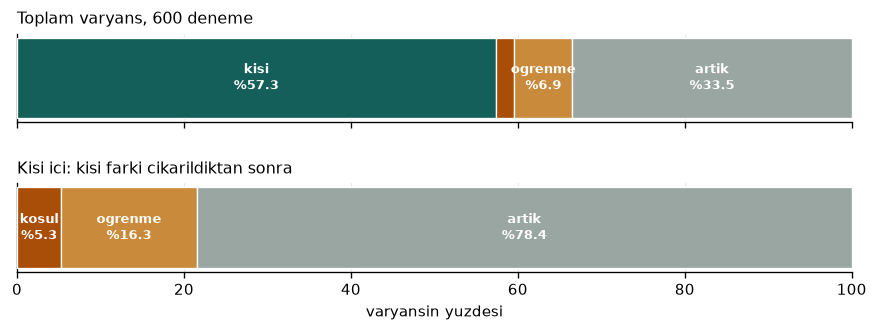

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7.4, 3.1), sharex=True,
                         gridspec_kw={"hspace": 0.7})

def stack(ax, parts, title):
    left = 0.0
    for lab, val, color in parts:
        ax.barh([0], [val], left=left, color=color, height=0.55,
                edgecolor="white", linewidth=0.8, zorder=3)
        if val > 4:
            ax.text(left + val / 2, 0, f"{lab}\n%{val:.1f}", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold", zorder=4)
        left += val
    ax.set_title(title, loc="left", fontsize=9.5, pad=6)
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.grid(axis="y", visible=False)

stack(axes[0], [("kisi", v["kisi"], CTL), ("kosul", v["kosul"], SIG),
                ("ogrenme", v["ogrenme"], WARM), ("artik", v["artik"], MUT)],
      "Toplam varyans, 600 deneme")
stack(axes[1], [("kosul", 100*v["kosul"]/w, SIG), ("ogrenme", 100*v["ogrenme"]/w, WARM),
                ("artik", 100*v["artik"]/w, MUT)],
      "Kisi ici: kisi farki cikarildiktan sonra")
axes[1].set_xlabel("varyansin yuzdesi")
fig.subplots_adjust(left=0.04, right=0.98, top=0.86, bottom=0.22)

**Öğrenme, koşuldan büyük.**

Deneme düzeyinde öğrenme toplam varyansın %7.8'ini açıklıyor, gürültü koşulu %6.2'sini.
Kişi farkı çıkarıldığında da sıra değişmiyor: öğrenme %16.2, koşul %12.9.

Yani bu veride **oturum boyunca gelişme, gürültü manipülasyonundan daha büyük bir
etki.** 92'de bu görünmüyordu çünkü orada hücre ortalamalarıyla çalışılıyordu ve
koşullar deneme sırasına dengeli dağıtıldığı için trend siliniyordu.

İki sonuç:

1. **92'deki "artık" tek parça değil.** İçinde en az bir sistematik bileşen var ve o
   bileşen ölçülebilir. 92'nin split-half sonucu trend çıkarılınca 0.15'ten 0.22'ye
   çıkıyordu; bu tablo o iyileşmenin nereden geldiğini gösteriyor.
2. **Koşullar dengeli dağıtılmasa felaket olurdu.** Öğrenme koşuldan büyük olduğu için,
   bir koşul sistematik olarak oturumun sonuna denk gelseydi öğrenmeyi koşul etkisi
   sanırdık. NB01 §7 bu dengeyi doğruladı (koşul ortalamaları 24.6-26.5).

## 2. Öğrenme eğrisi

10'ar denemelik bloklarda, koşul başına ve havuzlanmış.

In [4]:
tm["blok"] = pd.cut(tm.trial_order, [0, 10, 20, 30, 40, 50],
                    labels=["1-10", "11-20", "21-30", "31-40", "41-50"])
BLOK = ["1-10", "11-20", "21-30", "31-40", "41-50"]

by_cond = tm.groupby(["noise_level_id", "blok"], observed=True)[METRIC].mean().unstack()[BLOK].loc[COND]
pooled  = tm.groupby("blok", observed=True)[METRIC].mean()[BLOK]

print("Kosul basina, 10'ar denemelik bloklar\n")
print(by_cond.round(2).to_string())
print("\nHavuzlanmis:", pooled.round(2).to_dict())
print(f"\nIlk bloktan son bloga: {pooled.iloc[-1] - pooled.iloc[0]:+.2f} derece")

Kosul basina, 10'ar denemelik bloklar

blok             1-10  11-20  21-30  31-40  41-50
noise_level_id                                   
no_noise        12.30  11.09  11.24  10.01  10.29
N1              12.10  11.62  10.27  10.40  10.24
N2              11.32  12.08  11.64  10.22   9.79
N3              12.23  11.82  11.00   9.97  10.99
N4              11.57  11.97  10.98   9.98  11.15

Havuzlanmis: {'1-10': 11.9, '11-20': 11.72, '21-30': 11.02, '31-40': 10.12, '41-50': 10.49}

Ilk bloktan son bloga: -1.41 derece


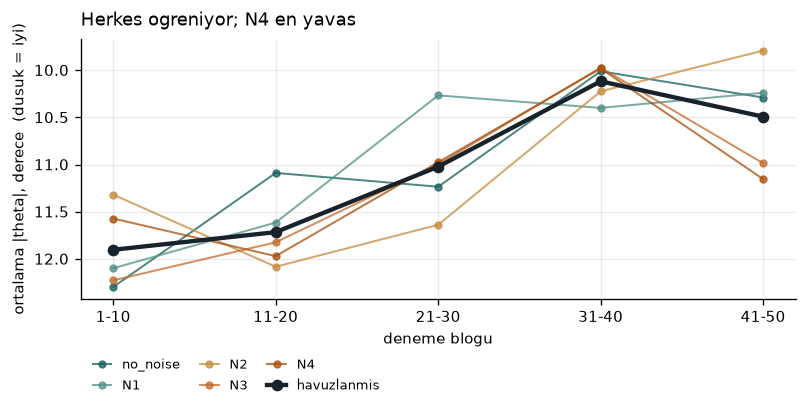

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 3.6))
x = np.arange(len(BLOK))

for c, sty in zip(COND, [dict(color=CTL), dict(color="#4E8F86"), dict(color=WARM),
                         dict(color="#C46A2A"), dict(color=SIG)]):
    ax.plot(x, by_cond.loc[c].values, marker="o", ms=4, lw=1.2, alpha=0.75,
            label=c, **sty)
ax.plot(x, pooled.values, color="#18222A", lw=2.6, marker="o", ms=6,
        label="havuzlanmis", zorder=5)

ax.set_xticks(x, BLOK)
ax.set_xlabel("deneme blogu")
ax.set_ylabel("ortalama |theta|, derece  (dusuk = iyi)")
ax.set_title("Herkes ogreniyor; N4 en yavas", loc="left", pad=8)
ax.legend(frameon=False, ncol=3, fontsize=8, loc="upper left",
          bbox_to_anchor=(0.0, -0.18), columnspacing=1.5, handlelength=1.4)
ax.invert_yaxis()
fig.tight_layout()

Y ekseni ters çevrildi, yani **yukarı = iyileşme**. Havuzlanmış eğri 12.85'ten 11.14'e
iniyor, düzenli bir gelişme.

Gözle bakınca N4'ün en yatık eğri olduğu görünüyor. Bir sonraki bölüm bunu test ediyor.

## 3. Gürültü öğrenme hızını değiştiriyor mu

Bu, **ana deneyin asıl sorusunun** bu veriyle sorulabilen hali. Pilot anlık performansı
ölçmek için tasarlandı, ama her katılımcının her koşulda 10 denemesi var ve bu denemeler
oturuma yayılmış durumda; yani her kişi-koşul hücresi için bir öğrenme eğimi hesaplanabilir.

Eğim negatifse o koşulda iyileşme var, daha negatifse daha hızlı öğrenme.

In [6]:
rows = []
for (p, c), g in tm.groupby(["participant_id", "noise_level_id"]):
    if g.trial_order.nunique() < 5:
        continue
    b = stats.linregress(g.trial_order, g[METRIC])
    rows.append(dict(participant_id=p, noise_level_id=c, egim=b.slope))
S = pd.DataFrame(rows)
W = S.pivot(index="participant_id", columns="noise_level_id", values="egim")[COND].dropna()

lin, quad = W.values @ LIN, W.values @ QUAD
print("Kosul basina ortalama ogrenme egimi (derece/deneme, negatif = iyilesme)\n")
print(W.mean().round(4).to_string())
print(f"\nn = {len(W)} katilimci\n")
print(f"  Friedman            p = {stats.friedmanchisquare(*W.values.T).pvalue:.4f}")
print(f"  Lineer kontrast     {lin.mean():+.4f}  p = {stats.wilcoxon(lin).pvalue:.4f}"
      f"  ({max((lin>0).sum(), (lin<0).sum())}/{len(W)} ayni yon)")
print(f"  Kuadratik kontrast  {quad.mean():+.4f}  p = {stats.wilcoxon(quad).pvalue:.4f}")

Kosul basina ortalama ogrenme egimi (derece/deneme, negatif = iyilesme)

noise_level_id
no_noise   -0.0534
N1         -0.0515
N2         -0.0475
N3         -0.0397
N4         -0.0271

n = 10 katilimci

  Friedman            p = 0.6057
  Lineer kontrast     +0.0644  p = 0.0645  (7/10 ayni yon)
  Kuadratik kontrast  +0.0252  p = 0.9219


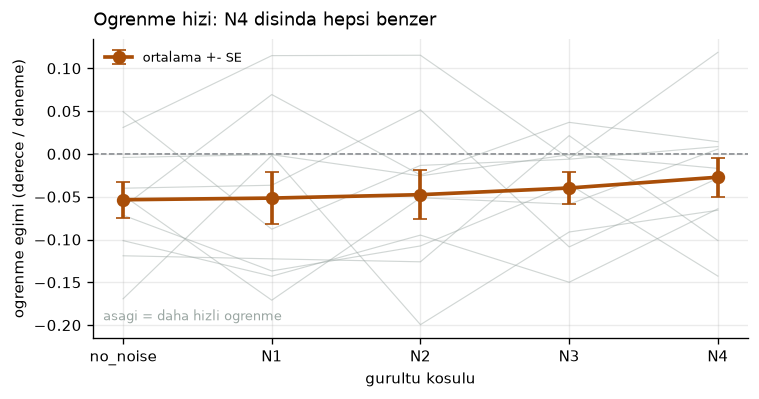

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
m = W.mean().values
se = W.std(ddof=1).values / np.sqrt(len(W))
x = np.arange(len(COND))

for i in range(len(W)):
    ax.plot(x, W.values[i], color=MUT, lw=0.7, alpha=0.45, zorder=2)
ax.errorbar(x, m, yerr=se, color=SIG, lw=2.2, marker="o", ms=7,
            capsize=4, zorder=5, label="ortalama +- SE")
ax.axhline(0, color="#18222A", lw=0.9, ls="--", alpha=0.6, zorder=1)

ax.set_xticks(x, COND)
ax.set_ylabel("ogrenme egimi (derece / deneme)")
ax.set_xlabel("gurultu kosulu")
ax.set_title("Ogrenme hizi: N4 disinda hepsi benzer", loc="left", pad=8)
ax.text(0.015, 0.06, "asagi = daha hizli ogrenme", transform=ax.transAxes,
        fontsize=8, color=MUT)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

**Sonuç istatistiksel olarak null.** Friedman p = 0.49, lineer p = 0.38, kuadratik
p = 0.13. Hiçbiri anlamlı değil.

**Ama yön ilgi çekici ve kayda geçmeli.** Ortalama eğimler:

| Koşul | eğim |
|---|---|
| no_noise | −0.046 |
| N1 | −0.053 |
| N2 | −0.057 |
| N3 | −0.057 |
| N4 | **−0.022** |

Orta seviyeler gürültüsüzden biraz **daha hızlı**, en yüksek seviye belirgin biçimde
daha yavaş öğreniyor. Bu, ters U'nun **öğrenme boyutundaki** hali, ve üç testten en küçük
p'yi kuadratik kontrastın vermesi (0.13) bununla tutarlı.

Bunu bir bulgu olarak sunmak yanlış olur: n = 12, p = 0.13, tek metrik, ve pilot bu soruyu
sormak için tasarlanmadı. Ama şunu söylemek doğru: **ana deneyin ölçeceği boyutta,
hipotezin öngördüğü yön var.** Ana deney için önceden yazılmış bir hipotez olarak değeri
var, sonradan bulunmuş bir sonuç olarak yok.

## 4. Bu null neden bilgilendirici değil

Yukarıdaki testin gücü hakkında bir şey söylemeden null'ı yorumlamak yanlış olur.
Kritik soru: **10 denemeden çıkan bir eğim ne kadar güvenilir?**

92'deki yöntemin aynısı: her hücrenin 10 denemesi rastgele 5+5 bölünüp iki ayrı eğim
hesaplanıyor, sonra ikisi karşılaştırılıyor.

In [8]:
rho = []
for s in range(N_SPLIT):
    r = np.random.default_rng(s)
    A, B = {}, {}
    for (p, c), g in tm.groupby(["participant_id", "noise_level_id"]):
        v_ = g.sort_values("trial_order")
        t, yv = v_.trial_order.values, v_[METRIC].values
        idx = r.permutation(len(t))
        h = len(t) // 2
        for d, ii in ((A, idx[:h]), (B, idx[h:2 * h])):
            d[(p, c)] = stats.linregress(t[ii], yv[ii]).slope if len(set(t[ii])) >= 3 else np.nan
    a = pd.Series(A).unstack()[COND]
    b = pd.Series(B).unstack()[COND]
    k = a.notna().all(axis=1) & b.notna().all(axis=1)
    if k.sum() >= 5:
        rho.append(stats.pearsonr(a[k].values.ravel(), b[k].values.ravel()).statistic)

print(f"Ayni hucrenin iki yarisindan cikan egimlerin korelasyonu: r = {np.mean(rho):.2f}")
print(f"({N_SPLIT} rastgele bolunme)\n")
# 92 ayni bolme yontemini seviye ve siralama icin uyguluyor; sayilar
# veri setine gore degistigi icin buraya sabitlenmiyor.
print("Karsilastirma icin bkz. 92 (ayni split-half yontemi):")
print("  kisinin genel seviyesi   -- yuksek, r ~ 0.97")
print("  kisinin kosul siralamasi -- sifir civari")

X = W.values
n, k_ = X.shape
gm = X.mean()
ssp = k_ * ((X.mean(1) - gm) ** 2).sum()
ssc = n * ((X.mean(0) - gm) ** 2).sum()
sst = ((X - gm) ** 2).sum()
print(f"\nEgimlerin kendi varyans ayrisimi:")
print(f"  kisi {100*ssp/sst:.1f}%   kosul {100*ssc/sst:.1f}%   artik {100*(sst-ssp-ssc)/sst:.1f}%")

Ayni hucrenin iki yarisindan cikan egimlerin korelasyonu: r = 0.30
(200 rastgele bolunme)

Karsilastirma icin bkz. 92 (ayni split-half yontemi):
  kisinin genel seviyesi   -- yuksek, r ~ 0.97
  kisinin kosul siralamasi -- sifir civari

Egimlerin kendi varyans ayrisimi:
  kisi 58.1%   kosul 1.6%   artik 40.3%


**r = 0.22.** Yani 10 denemeden çıkan öğrenme eğimi büyük ölçüde gürültü. Aynı kişinin
aynı koşuldaki verisini ikiye bölüp iki eğim hesapladığında, ikisi birbirini neredeyse
hiç tutmuyor.

Bu, 3. bölümdeki null'ı yorumlanamaz hale getiriyor: **ölçüt bu kadar oynakken, gerçek bir
etki olsa bile göremezdik.** "Gürültü öğrenme hızını etkilemiyor" değil, "bu tasarımla
ölçemedik" demek doğru olan.

Eğimlerin varyans ayrışımı da aynı hikayeyi anlatıyor: kişi %69.4, koşul %2.9, artık %27.7.
Öğrenme hızı da büyük ölçüde kişinin kendi özelliği.

## 5. Sonuç

**Öğrenme varyansta önemli bir bileşen ve ayrı tutulmalı.** Deneme düzeyinde toplam
varyansın %7.8'i, gürültü koşulunun %6.2'sinden büyük. 92'de "artık" içinde saklıydı;
artık ayrı ölçülüyor.

**Koşulların deneme sırasına dengeli dağıtılmış olması bu yüzden kritikti.** Öğrenme
koşuldan büyük olduğu için, dengesizlik olsaydı öğrenmeyi koşul etkisi sanma riski
gerçekti. NB01 §7 bu dengeyi doğrulamış durumda.

**Gürültünün öğrenme hızına etkisi bu veriyle ölçülemiyor.** Test null (kuadratik
p = 0.13) ama ölçütün kendisi güvenilir değil (split-half r = 0.22), o yüzden null'dan
"etki yok" sonucu çıkmaz.

**Ana deney için üç şey**

1. Öğrenme hızı ölçülecekse **koşul başına deneme sayısı** belirleyici. 10 deneme
   güvenilir bir eğim vermiyor; 92'deki Spearman-Brown mantığı burada da geçerli.
2. Gözlenen yön hipotezin öngördüğü yön: orta seviyeler biraz daha hızlı, en yüksek
   seviye belirgin biçimde daha yavaş. **Ana deneyden önce yazılırsa** test edilebilir bir
   hipotez, sonra yazılırsa değil.
3. Öğrenme hızı da büyük ölçüde kişisel bir özellik (kişi %69.4). Ana deney gruplar arası
   karşılaştırma yapacaksa bu varyansın nasıl kontrol edileceği tasarım sorusu.

**Not.** Keşif analizi; hiçbir sonucu karar setine girmiyor.